In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
df.shape

(100, 4)

In [ ]:
df=df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [ ]:
import matplotlib.pyplot as plt

/tmp/ipykernel_286/3362959894.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


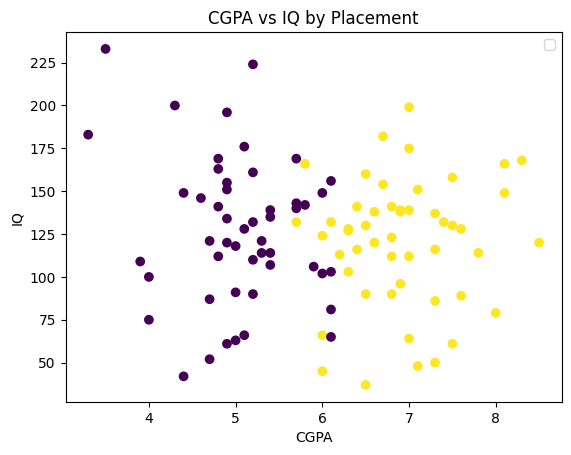

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('CGPA vs IQ by Placement')
plt.legend()
plt.show()

In [ ]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [ ]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
x.shape

(100, 2)

In [ ]:
y.shape

(100,)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [ ]:
x_train

,cgpa,iq
67,5.0,118.0
78,6.1,81.0
82,6.5,37.0
84,5.7,169.0
80,4.9,196.0
...,...,...
86,5.1,128.0
64,7.0,64.0
56,6.1,65.0
98,6.3,103.0


In [ ]:
y_train

,placement
67,0
78,0
82,1
84,0
80,0
...,...
86,0
64,1
56,0
98,1


In [ ]:
x_test

,cgpa,iq
94,4.7,52.0
73,4.9,61.0
32,7.0,139.0
21,7.1,151.0
19,5.2,132.0
39,4.6,146.0
93,6.8,112.0
9,5.1,66.0
27,6.0,124.0
61,7.3,137.0


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
x_train=scaler.fit_transform(x_train)

In [ ]:
x_train

array([[-0.87485255, -0.17191972],
       [ 0.08322712, -1.09828325],
       [ 0.43161973, -2.19990474],
       [-0.26516548,  1.10495974],
       [-0.9619507 ,  1.78095475],
       [-1.04904885, -0.32214083],
       [-0.17806733,  0.42896473],
       [ 1.5638957 , -0.27206713],
       [ 0.25742343,  0.0784488 ],
       [-0.00387103,  0.6042227 ],
       [-1.136147  , -0.94806214],
       [ 1.30260125,  0.12852251],
       [-1.136147  , -0.09680916],
       [ 2.17358277, -0.12184601],
       [ 0.34452158,  0.40392788],
       [ 0.60581603,  1.43043882],
       [-0.61355809, -0.09680916],
       [-2.18132482,  2.70731828],
       [-0.52645994, -0.44732509],
       [ 1.73809201, -1.14835695],
       [-0.7877544 ,  1.28021771],
       [-1.04904885,  0.95473863],
       [-1.74583407, -1.24850436],
       [ 1.3896994 ,  0.0784488 ],
       [-0.00387103, -0.57250935],
       [-0.26516548,  0.37889103],
       [ 1.99938646,  1.07992289],
       [ 1.12840494, -0.97309899],
       [-0.17806733,

In [ ]:
x_test = scaler.transform(x_test)

In [ ]:
x_test

array([[-1.136147  , -1.82435196],
       [-0.9619507 , -1.59902029],
       [ 0.86711049,  0.35385418],
       [ 0.95420864,  0.6542964 ],
       [-0.70065624,  0.17859621],
       [-1.22324515,  0.52911214],
       [ 0.69291419, -0.32214083],
       [-0.7877544 , -1.47383603],
       [-0.00387103, -0.02169861],
       [ 1.12840494,  0.30378047]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf=LogisticRegression()

In [ ]:
# model training
clf.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=clf.predict(x_test)

In [ ]:
y_test

,placement
94,0
73,0
32,1
21,1
19,0
39,0
93,1
9,0
27,1
61,1


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.9

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

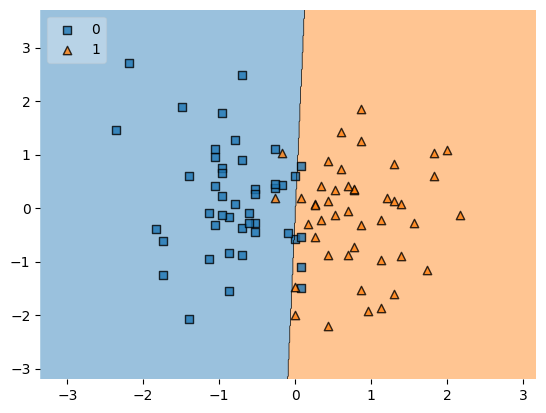

In [40]:
plot_decision_regions(x_train,y_train.values, clf=clf, legend=2)

In [41]:
import pickle

In [42]:
pickle.dump(clf,open('model.pkl','wb'))